# **1. Perkenalan Dataset**
Dataset yang digunakan adalah Titanic Survival Prediction. Dataset ini berisi data penumpang kapal Titanic dan digunakan untuk memprediksi apakah seorang penumpang selamat atau tidak (target `Survived`).
- **Sumber Dataset**: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv


# **2. Import Library**
Pada tahap ini, kita mengimpor library untuk pengolahan data dan visualisasi.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for seaborn
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')


# **3. Memuat Dataset**
Memuat dataset titanic dari github raw url.


In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("Data Shape:", df.shape)
df.head()


Data Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **4. Exploratory Data Analysis (EDA)**
EDA bertujuan untuk mengeksplorasi data dan menemukan wawasan penting. Kita akan membuat minimal 8-10 visualisasi.


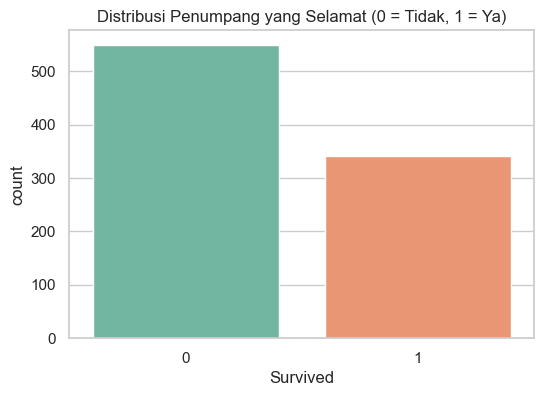

In [3]:
# 1. Distribusi Target (Survived)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Survived', palette='Set2')
plt.title('Distribusi Penumpang yang Selamat (0 = Tidak, 1 = Ya)')
plt.show()


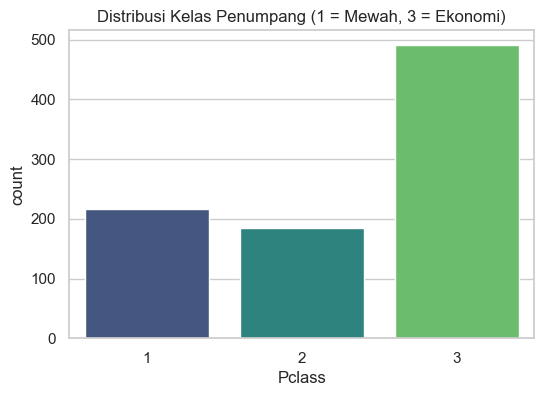

In [4]:
# 2. Distribusi Kelas Penumpang (Pclass)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Pclass', palette='viridis')
plt.title('Distribusi Kelas Penumpang (1 = Mewah, 3 = Ekonomi)')
plt.show()


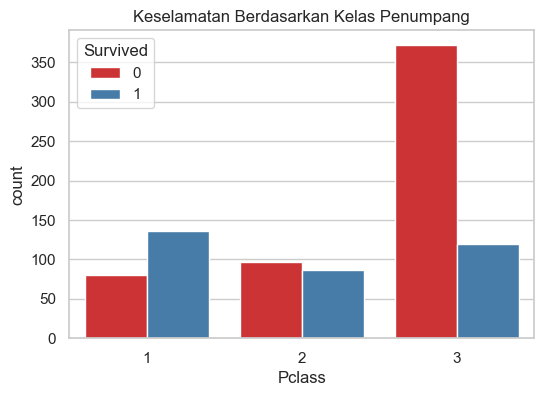

In [5]:
# 3. Keselamatan berdasarkan Kelas Penumpang
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Pclass', hue='Survived', palette='Set1')
plt.title('Keselamatan Berdasarkan Kelas Penumpang')
plt.show()


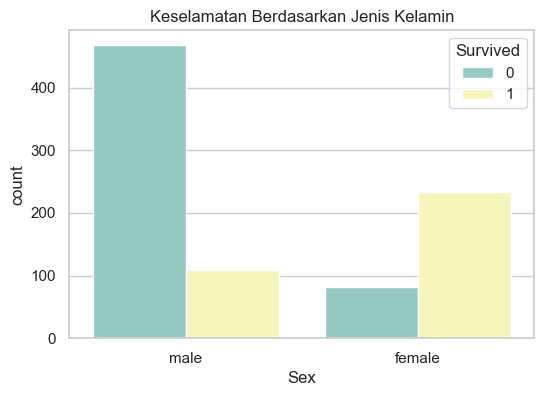

In [6]:
# 4. Keselamatan berdasarkan Jenis Kelamin
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Sex', hue='Survived', palette='Set3')
plt.title('Keselamatan Berdasarkan Jenis Kelamin')
plt.show()


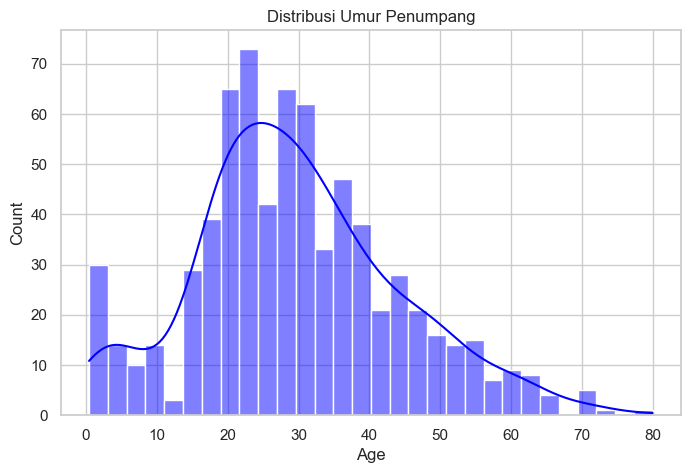

In [7]:
# 5. Distribusi Umur Penumpang
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'].dropna(), kde=True, color='blue', bins=30)
plt.title('Distribusi Umur Penumpang')
plt.show()


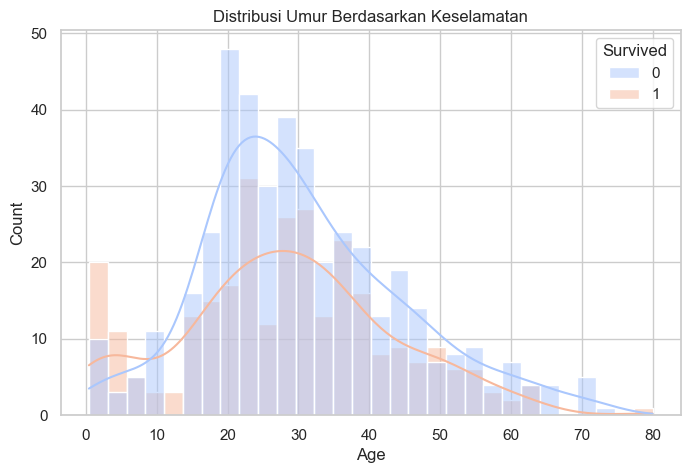

In [8]:
# 6. Distribusi Umur berdasarkan Keselamatan
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, palette='coolwarm', bins=30)
plt.title('Distribusi Umur Berdasarkan Keselamatan')
plt.show()


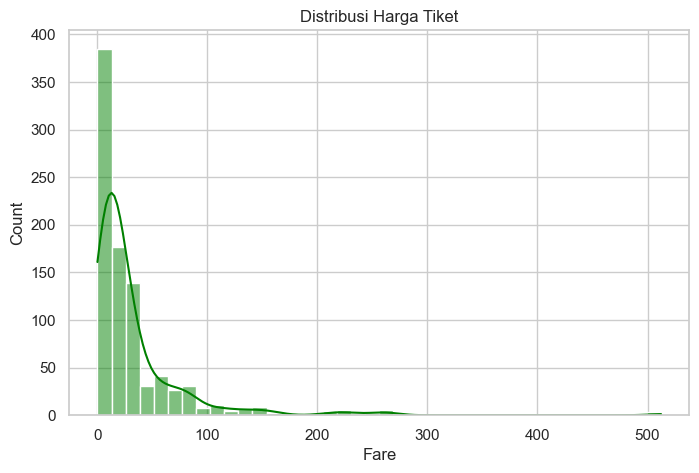

In [9]:
# 7. Distribusi Harga Tiket (Fare)
plt.figure(figsize=(8, 5))
sns.histplot(df['Fare'], kde=True, color='green', bins=40)
plt.title('Distribusi Harga Tiket')
plt.show()


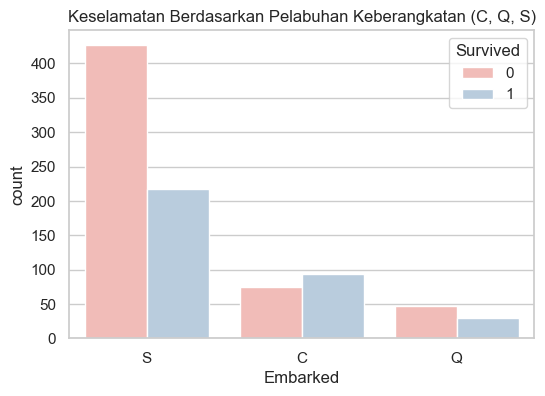

In [10]:
# 8. Keselamatan berdasarkan Pelabuhan Keberangkatan (Embarked)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Embarked', hue='Survived', palette='Pastel1')
plt.title('Keselamatan Berdasarkan Pelabuhan Keberangkatan (C, Q, S)')
plt.show()


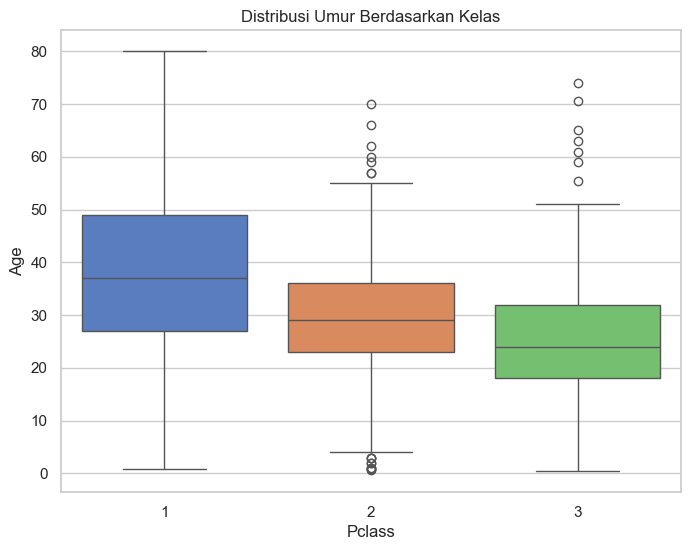

In [11]:
# 9. Boxplot Umur vs Kelas Penumpang
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Pclass', y='Age', palette='muted')
plt.title('Distribusi Umur Berdasarkan Kelas')
plt.show()


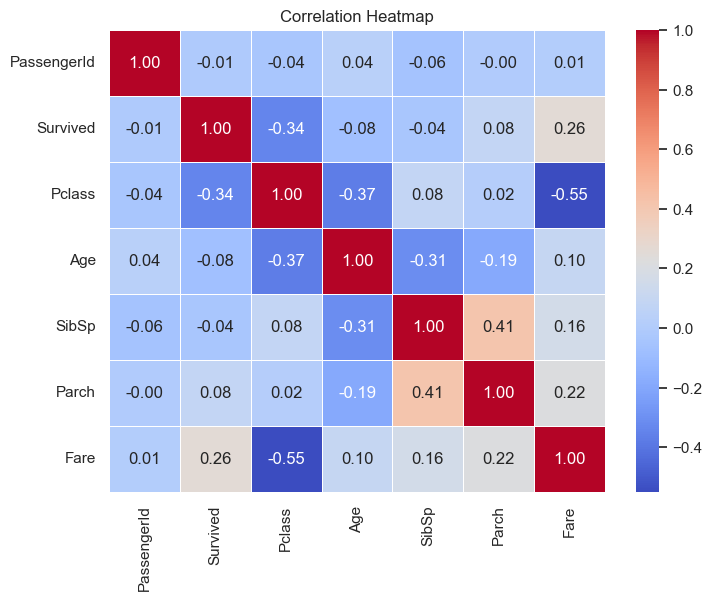

In [12]:
# 10. Correlation Heatmap untuk Fitur Numerik
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


# **5. Data Preprocessing**
Tahap ini meliputi handling missing values, encoding, dan persiapan data.


In [13]:
# Cek missing values
print("Missing Values Sebelum Imputasi:")
print(df.isnull().sum())


Missing Values Sebelum Imputasi:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [14]:
# 1. Menangani Missing Values
# Umur (Age) diisi dengan median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Pelabuhan keberangkatan (Embarked) diisi dengan modus
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop kolom Cabin karena terlalu banyak missing value
df.drop('Cabin', axis=1, inplace=True)

print("\nMissing Values Setelah Imputasi:")
print(df.isnull().sum())



Missing Values Setelah Imputasi:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [15]:
# 2. Encoding Data Kategorikal (Manual)
# Sex (Male = 0, Female = 1)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Embarked menggunakan One-Hot Encoding
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)


In [16]:
# 3. Drop kolom yang tidak digunakan (Name, Ticket, PassengerId)
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [17]:
# 4. Pemisahan Fitur dan Target
X = df.drop('Survived', axis=1)
y = df['Survived']

print("Dimensi X:", X.shape)
print("Dimensi y:", y.shape)


Dimensi X: (891, 8)
Dimensi y: (891,)


In [18]:
# 5. Scaling (Standardization)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_final = pd.DataFrame(X_scaled, columns=X.columns)
X_final.head()


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0.827377,-0.737695,-0.565736,0.432793,-0.473674,-0.502445,-0.307562,0.615838
1,-1.566107,1.355574,0.663861,0.432793,-0.473674,0.786845,-0.307562,-1.623803
2,0.827377,1.355574,-0.258337,-0.474545,-0.473674,-0.488854,-0.307562,0.615838
3,-1.566107,1.355574,0.433312,0.432793,-0.473674,0.420730,-0.307562,0.615838
4,0.827377,-0.737695,0.433312,-0.474545,-0.473674,-0.486337,-0.307562,0.615838


# **6. Kesimpulan**
Eksperimen data preprocessing secara manual telah berhasil dilakukan. Proses ini juga dapat diautomasi menggunakan sklearn pipeline seperti pada file `automate_MochamadChairulridjalNurvikri.py`.
